# 📊 Sentiment Analysis — Final User-Level Summary

This notebook takes the final classified sentiment data (`sentiment_final.csv`) and answers  
three core business questions:

1. **How many users are Positive, Negative, or Neutral overall?**
2. **What is the overall sentiment of the entire survey?**
3. **Per-user breakdown — what did each respondent feel across all their answers?**


## 1. Load Final Sentiment Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

open_text_data = pd.read_csv('sentiment_final.csv')
print(open_text_data.shape)
open_text_data.head()

(3452, 3)


In [2]:
open_text_data['responseID'].nunique()

613


## 2. Overall Sentiment Distribution (All Responses)

First, let's see the raw count of Positive / Negative / Neutral labels across all responses.

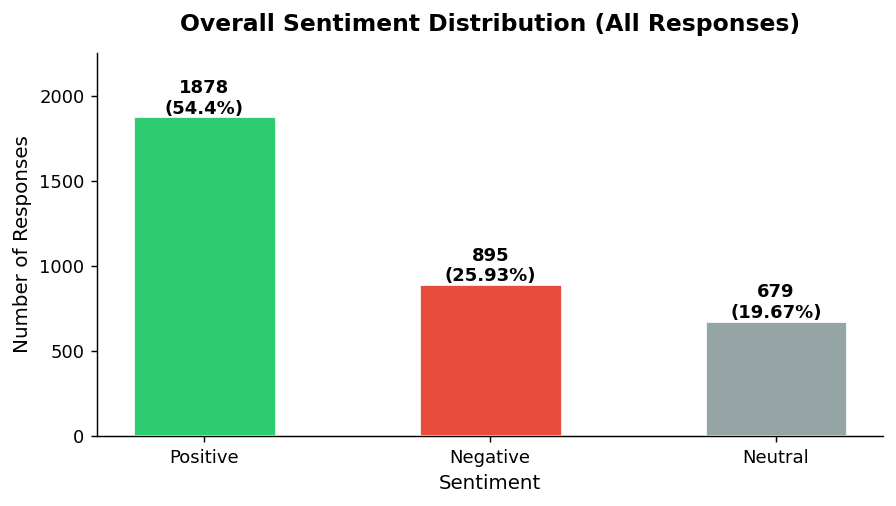

In [3]:
open_text_data['sentiment'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c','#95a5a6'])
plt.title('Overall Sentiment — All Responses')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()

Exact counts and percentages:

In [4]:
overall = open_text_data['sentiment'].value_counts().reset_index()
overall.columns = ['Sentiment', 'Count']
overall['Percentage'] = (overall['Count'] / overall['Count'].sum() * 100).round(2)
print("=== Overall Sentiment Distribution (All Responses) ===")
print(overall.to_string(index=False))
print(f"\nTotal Responses: {overall['Count'].sum()}")

=== Overall Sentiment Distribution (All Responses) ===
Sentiment  Count  Percentage
 Positive   1878       54.40
 Negative    895       25.93
  Neutral    679       19.67

Total Responses: 3452


## 3. Overall Survey Verdict

Based on the majority sentiment across all responses — is this survey overall Positive, Negative, or Neutral?

In [5]:
dominant = open_text_data['sentiment'].value_counts().idxmax()
dominant_pct = (open_text_data['sentiment'].value_counts().max() / len(open_text_data) * 100).round(2)

print("=" * 45)
print(f"  OVERALL SURVEY VERDICT: {dominant.upper()}")
print(f"  Dominant sentiment with {dominant_pct}% of all responses")
print("=" * 45)

  OVERALL SURVEY VERDICT: POSITIVE
  Dominant sentiment with 54.4% of all responses


## 4. Per-User Sentiment Classification

Each respondent answered multiple questions. We classify each user's **overall sentiment**  
by taking the majority sentiment across all their answers.

- If a user has more Positive answers → they are **Positive**
- If more Negative → **Negative**
- If tied or mostly Neutral → **Neutral**


In [6]:
user_sentiment = open_text_data.groupby('responseID')['sentiment'].value_counts().unstack(fill_value=0)

for col in ['Positive', 'Negative', 'Neutral']:
    if col not in user_sentiment.columns:
        user_sentiment[col] = 0

user_sentiment = user_sentiment.reset_index()
user_sentiment.columns.name = None

def get_user_verdict(row):
    scores = {'Positive': row.get('Positive', 0), 
              'Negative': row.get('Negative', 0), 
              'Neutral':  row.get('Neutral', 0)}
    max_score = max(scores.values())
    top = [k for k, v in scores.items() if v == max_score]
    if len(top) == 1:
        return top[0]
    for label in ['Positive', 'Neutral', 'Negative']:
        if label in top:
            return label

user_sentiment['user_verdict'] = user_sentiment.apply(get_user_verdict, axis=1)
user_sentiment['total_responses'] = user_sentiment['Positive'] + user_sentiment['Negative'] + user_sentiment['Neutral']

print(user_sentiment[['responseID','Positive','Negative','Neutral','total_responses','user_verdict']].head(20).to_string(index=False))

 responseID  Positive  Negative  Neutral  total_responses user_verdict
  142317923         3         1        1                5     Positive
  142317927         1         2        1                4     Negative
  142317931         1         2        1                4     Negative
  142317957         3         1        2                6     Positive
  142317958         2         2        2                6     Positive
  142317969         4         0        2                6     Positive
  142317971         3         3        0                6     Positive
  142317986         4         3        3               10     Positive
  142317995         4         2        0                6     Positive
  142318001         3         4        1                8     Negative
  142318003         3         2        1                6     Positive
  142318013         5         2        0                7     Positive
  142318031         2         1        0                3     Positive
  1423

## 5. How Many Users are Positive, Negative, Neutral?

  USER-LEVEL SENTIMENT SUMMARY
Sentiment  User Count  Percentage
 Positive         470       79.39
 Negative          77       13.01
  Neutral          45        7.60

  Total Unique Users: 592


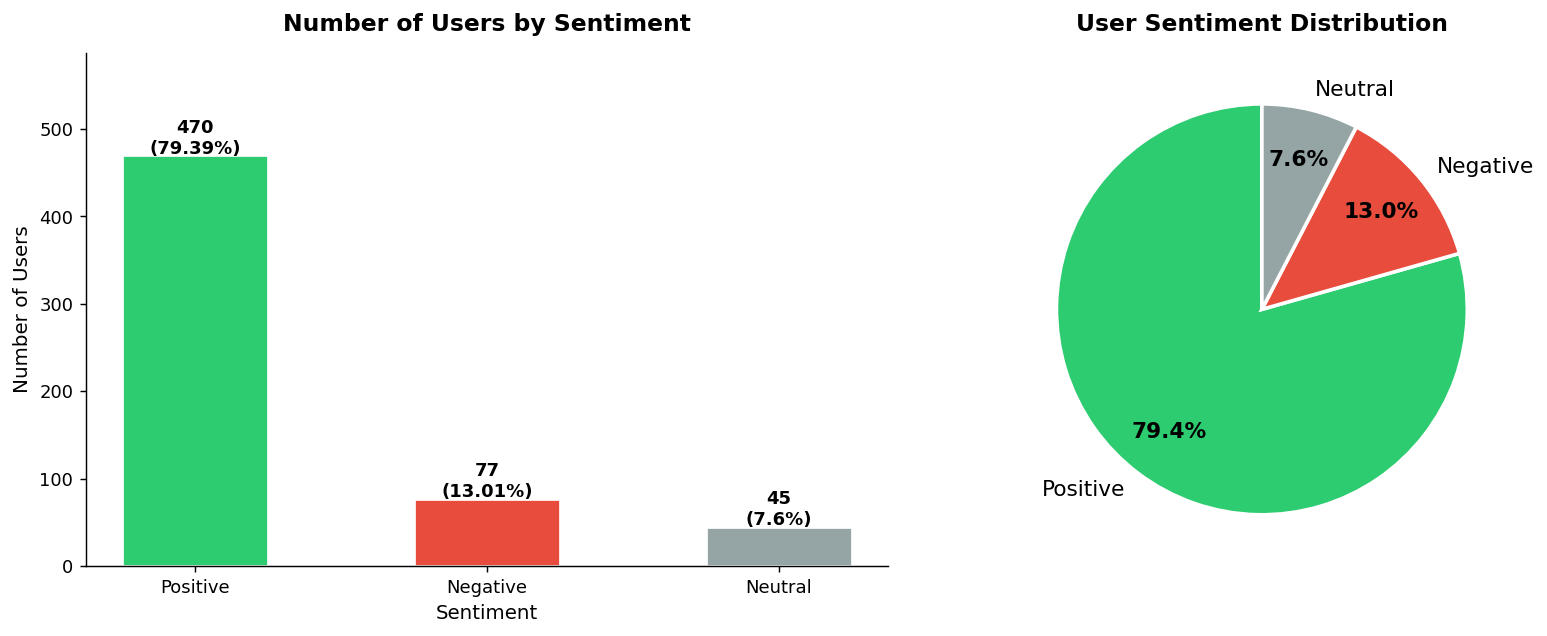

In [7]:
user_counts = user_sentiment['user_verdict'].value_counts().reset_index()
user_counts.columns = ['Sentiment', 'User Count']
user_counts['Percentage'] = (user_counts['User Count'] / user_counts['User Count'].sum() * 100).round(2)

print("=" * 50)
print("  USER-LEVEL SENTIMENT SUMMARY")
print("=" * 50)
print(user_counts.to_string(index=False))
print(f"\n  Total Unique Users: {user_sentiment['responseID'].nunique()}")
print("=" * 50)

colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
bar_colors = [colors.get(s, '#3498db') for s in user_counts['Sentiment']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(user_counts['Sentiment'], user_counts['User Count'], color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Number of Users by Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Users')
axes[1].pie(user_counts['User Count'], labels=user_counts['Sentiment'], autopct='%1.1f%%',
            colors=bar_colors, startangle=90)
axes[1].set_title('User Sentiment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Overall User-Level Verdict

In [8]:
dominant_users = user_sentiment['user_verdict'].value_counts().idxmax()
dominant_users_count = user_sentiment['user_verdict'].value_counts().max()
total_users = user_sentiment['responseID'].nunique()
dominant_users_pct = round(dominant_users_count / total_users * 100, 2)

print("=" * 50)
print(f"  OVERALL USER VERDICT: {dominant_users.upper()}")
print(f"  {dominant_users_count} out of {total_users} users ({dominant_users_pct}%) are {dominant_users}")
print("=" * 50)

  OVERALL USER VERDICT: POSITIVE
  470 out of 592 users (79.39%) are Positive


## 7. Response Pattern by User Verdict Group

Average number of Positive / Negative / Neutral responses per user — broken down by their overall verdict.

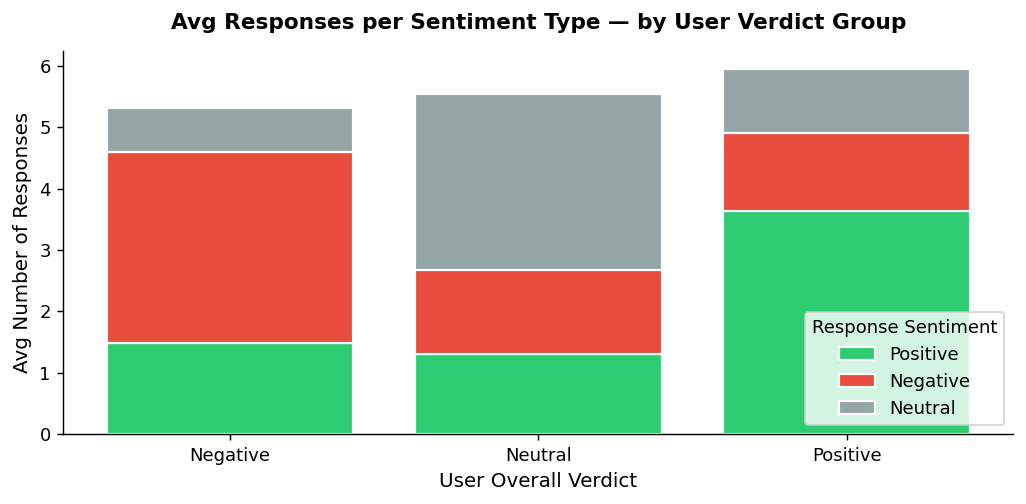

In [9]:
grouped = user_sentiment.groupby('user_verdict')[['Positive','Negative','Neutral']].mean().round(2)
grouped.plot(kind='bar', color=['#2ecc71','#e74c3c','#95a5a6'], figsize=(8,4), edgecolor='white')
plt.title('Avg Responses per Sentiment Type — by User Verdict Group', fontweight='bold')
plt.xlabel('User Overall Verdict')
plt.ylabel('Avg Number of Responses')
plt.xticks(rotation=0)
plt.legend(title='Response Sentiment')
plt.tight_layout()
plt.show()

## 8. Per-User Detailed Breakdown

Full breakdown of each user — how many Positive, Negative, Neutral responses they gave,  
and their final verdict.

In [10]:
summary_table = user_sentiment[['responseID','Positive','Negative','Neutral','total_responses','user_verdict']]
summary_table = summary_table.sort_values(['user_verdict','total_responses'], ascending=[True, False])
print(f"Total Users: {len(summary_table)}")
print(summary_table.head(30).to_string(index=False))

Total Users: 592
 responseID  Positive  Negative  Neutral  total_responses user_verdict
  142319013         3         4        2                9     Negative
  142318001         3         4        1                8     Negative
  142318824         2         5        1                8     Negative
  142330132         2         5        1                8     Negative
  142336370         1         5        2                8     Negative
  142346915         2         5        1                8     Negative
  142319513         2         3        2                7     Negative
  142319878         2         4        1                7     Negative
  142319881         3         4        0                7     Negative
  142319891         2         3        2                7     Negative
  142320464         2         4        1                7     Negative
  142321267         2         3        2                7     Negative
  142322291         2         4        1                7   

## 9. Export Final Results

In [11]:
summary_table.to_csv('user_sentiment_summary.csv', index=False)
print("✅ Saved: user_sentiment_summary.csv")
print(f"   Rows: {len(summary_table)} users")
print(f"   Columns: {list(summary_table.columns)}")

✅ Saved: user_sentiment_summary.csv
   Rows: 592 users
   Columns: ['responseID', 'Positive', 'Negative', 'Neutral', 'total_responses', 'user_verdict']


---

## ✅ Business Summary

| Question | Answer |
|---|---|
| Total respondents analysed | 592 users |
| Overall survey verdict | **Positive** (54.4% of all responses) |
| Positive users | 470 users (79.39%) |
| Classification method | Majority sentiment across all responses per user |
| Output file | `user_sentiment_summary.csv` |

**How to read the results:**
- A user is **Positive** if most of their answers were classified as Positive
- A user is **Negative** if most of their answers were classified as Negative
- A user is **Neutral** if most answers were Neutral, or if there was a tie

This output can be directly used by business teams to:
- Identify dissatisfied respondents for follow-up
- Measure overall programme/product satisfaction
- Segment users by sentiment for targeted action
